In [43]:
import pandas as pd
import numpy as np
import re

In [19]:
df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_cleaned_v1.csv")

In [20]:
df.head(1)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,not available,6.0,NaN,undefined,"['HUDA Metro Station', 'Idea Cosmic Plaza', 'Gurugram Road', 'Dwarka Expy', 'GEMS International School', 'The NorthCap University', 'Aryan Hospital', 'Indira Gandhi Intl Airport']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN


**There are 5 Columns using which we can extract some important information :**

1.areaWithType

2.additionalRoom

3.agepossession

4.furnish Details

5.features

Handling Area with Type Column

In [42]:
df[['area','areaWithType']].sample(5)

,area,areaWithType
3649,1800.0,Plot area 200(167.23 sq.m.)
2715,2965.0,Super Built up area 2965(275.46 sq.m.)
2051,1245.0,Super Built up area 1245(115.66 sq.m.)Built Up area: 1154 sq.ft. (107.21 sq.m.)Carpet area: 945 sq.ft. (87.79 sq.m.)
2706,4739.0,Super Built up area 4739(440.27 sq.m.)Built Up area: 3655.35 sq.ft. (339.59 sq.m.)
428,1929.0,Super Built up area 1929(179.21 sq.m.)Built Up area: 1550 sq.ft. (144 sq.m.)Carpet area: 1330 sq.ft. (123.56 sq.m.)


The Problem here is , We have 3 types of area Carpet Area , BuiltUp Area and Super Built Up Area for flats and for houses/Indepenedent houses we have plot area. 

And the Units for all the Areas are different , but we should follow sqft. (For all the area calculations)

As a Part of our solution our first step should be fetching the three different areas -> BuiltUpArea , Carpet Area , Super Built Up Area

In [44]:
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)' , text)
    if match :
        return float(match.group(1))
    return None

In [60]:
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

Conversion into Sqft values

In [50]:
def convert_to_sqft(text,area_value):
    if area_value is None :
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [55]:
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda row: convert_to_sqft(row['areaWithType'], row['super_built_up_area']), axis=1)

In [61]:
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

In [62]:
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [58]:
df.drop(columns=['super_built_up_area_sqft'], inplace=True)

In [73]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2113,5.88,house,2160.0,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
37,4.30,house,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 sq.ft. (13.47 sq.m.),NaN,145.0,NaN
2637,1.80,flat,1889.0,Super Built up area 1889(175.49 sq.m.),1889.0,NaN,NaN
1191,0.41,flat,594.0,Carpet area: 601 (55.83 sq.m.),NaN,NaN,601.0
1713,1.00,flat,1554.0,Super Built up area 1554(144.37 sq.m.),1554.0,NaN,NaN


In [74]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

Where all the 3 features super_built_up_area	built_up_area	carpet_area are NAN it is a house data meaning it will have a plot area

In [84]:
df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())].sample(1)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
1138,house,independent,sector 50,10.55,32562.0,3240.0,Plot area 360(301.01 sq.m.),5,5,3,"study room,servant room",2.0,NaN,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Standard chartered ATM', 'Icici bank ATM', 'Vatsalya Clinic', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Vishesh Dental', 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Dr. Naresh Pandita', 'Dr. Anuj Sharma', 'Dr. Aruna Kalra', 'Wellness Eye Centre', 'Skin Clinic', 'Best Urologist Atcomplete Family Clinic', 'Divine Look Clinic Centre', 'Sukhmani Hospital Pvt. Ltd', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Wembley estate club', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'SPAZE BUSINESS PARK', 'Unitech', 'India Oil', 'Hdfc bank', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank', 'Indusind bank', 'SRS Cinemas', 'Madison and Pike', 'India', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Starbucks', 'Nook', 'Kamla International', 'Gurugram University', 'Delhi Public School Primary Section', 'Amity Global School', 'Manav Rachna School', 'St. Angels Sr', 'Manav Rachna Swimming Pool']",NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Club house / Community Center']",NaN,NaN,NaN


In [86]:
all_nan_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [87]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
11,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
12,3.75,house,160.0,Plot area 160(14.86 sq.m.),NaN,NaN,NaN
14,2.90,house,2500.0,Plot area 2500(232.26 sq.m.),NaN,NaN,NaN
18,11.25,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


So where we have property_type as house , All the 3 Super built up area , built up area and carpet area are NAN

In [88]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

**Plot Area is Equivalent to Built Up Area**

In [91]:
def get_plot_area(text):
    match = re.search(r'Plot area (\d+\.?\d*)',text)
    if match :
        return float(match.group(1))
    return None

In [105]:
all_nan_df['areaWithType'].sample(5)

288         Plot area 550(459.87 sq.m.)
2656          Plot area 60(50.17 sq.m.)
461     Plot area 1185.51(110.14 sq.m.)
2485         Plot area 263(219.9 sq.m.)
1735         Plot area 107(89.47 sq.m.)
Name: areaWithType, dtype: object

In [106]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(get_plot_area)

In [108]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.0,NaN
11,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.0,NaN
12,3.75,house,160.0,Plot area 160(14.86 sq.m.),NaN,160.0,NaN
14,2.90,house,2500.0,Plot area 2500(232.26 sq.m.),NaN,2500.0,NaN
18,11.25,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN


In [109]:
all_nan_df['built_up_area'].isnull().sum()

np.int64(0)

In [110]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN
11,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
12,3.75,house,160.0,Plot area 160(14.86 sq.m.),NaN,160.00,NaN
14,2.90,house,2500.0,Plot area 2500(232.26 sq.m.),NaN,2500.00,NaN
18,11.25,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
41,4.70,house,2160.0,Plot area 240(200.67 sq.m.),NaN,240.00,NaN
56,0.95,house,450.0,Plot area 450(41.81 sq.m.),NaN,450.00,NaN
60,0.80,house,981.0,Plot area 109(91.14 sq.m.),NaN,109.00,NaN
64,9.54,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
71,7.50,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN


We need to bring Plot Area into same unit. 

Plot Area is Having 2 units 

1. Square Yard 

2. Square Metre

But , our dataset follows Square Feet. 

So , the conversion scale will be 

1. For Square yard : 1 Square yard = 9 Square feet

2. For Sqaure Metre = 1 Square Metre = 10.7*Square Feet

In [111]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [112]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [113]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN
11,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
12,3.75,house,160.0,Plot area 160(14.86 sq.m.),NaN,160.00,NaN
14,2.90,house,2500.0,Plot area 2500(232.26 sq.m.),NaN,2500.00,NaN
18,11.25,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
41,4.70,house,2160.0,Plot area 240(200.67 sq.m.),NaN,2160.00,NaN
56,0.95,house,450.0,Plot area 450(41.81 sq.m.),NaN,450.00,NaN
60,0.80,house,981.0,Plot area 109(91.14 sq.m.),NaN,981.00,NaN
64,9.54,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
71,7.50,house,1935.0,Plot area 215(179.77 sq.m.),NaN,1935.00,NaN


In [114]:
df.update(all_nan_df)

In [115]:
df.isnull().sum()

property_type               0
society                     1
sector                      0
price                      17
price_per_square_feet      17
area                       17
areaWithType                0
bedRoom                     0
bathroom                    0
balcony                     0
additionalRoom              0
floorNum                   19
facing                   1104
agePossession               1
nearbyLocations           177
furnishDetails            980
features                  635
super_built_up_area      1887
built_up_area            2068
carpet_area              1858
dtype: int64

2. Handling Additional Room 

In [117]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1585
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [130]:
df[df['additionalRoom'] == "pooja room,study room,servant room,store room"].head(1)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
64,house,dlf city plots phase 4,sector 28,9.54,29444.0,3240.0,Plot area 360(301.01 sq.m.),6,5,3+,"pooja room,study room,servant room,store room",3.0,North,Within 6 months,"['Dlf phase 1 metro station', 'Huda city centre metro station', 'Iffco chowk metro station', 'Sector 42-43 metro station', 'New Life Church', 'Hanuman Mandir', 'Kotak mahindra bank ATM', 'Standard chartered ATM', 'Rbs ATM', 'Sitaram Bhartia', 'Max Hospital', 'Dr. Kutbuddin Akbary', 'Sidhesh Hospital Gurgaon', 'Marwah Clinic', 'Umkal Hospital', 'Dr. Naval Mendiratta', 'Gupta', 'Lord Krishna Hospital', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Divine Look Clinic Centre 1', 'Chikitsa', 'Guardian Pharmacy', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Indusind bank', 'Abn amro bank', 'Lord krishna bank', 'DT Cinemas', 'Blue Tokai Coffee Roasters', 'Starbucks', 'Nowhere Brewpub and cafe', 'Fat', 'Dighent cafe', 'Drunken Monkey', 'Belgian Waffle', 'CCD', 'The Chicken Boat', 'Naveidyam', 'Balaji Vegetarian Paradise', 'Pizza Hut', 'Barbecue Grill', 'PWO house', 'Food Court', 'Stones2milestones', 'Bahrisons library', 'Ncr library']","['2 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Internet/wi-fi connectivity', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,3240.0,NaN


In [131]:
df['additionalRoom'].str.split(',')

0                                          [not available]
1                                                 [others]
2                                                 [others]
3                                           [servant room]
4                                          [not available]
5                                          [not available]
6                                             [study room]
7                                          [not available]
8                                           [servant room]
9                                           [servant room]
10                                         [not available]
11                              [study room, servant room]
12                                          [servant room]
13                                          [servant room]
14                                          [servant room]
15                                          [servant room]
16                                         [not availabl

In [118]:
df['additionalRoom'].isnull().sum()

np.int64(0)

In [119]:
st = set()

In [132]:
def get_unique_rooms(room):
    for un_room in room :
        st.add(un_room)

In [ ]:
df['additionalRoom'].apply(lambda x : get_unique_rooms(x.split(',')))

In [134]:
print(st)

{'study room', 'servant room', 'store room', 'pooja room', 'not available', 'others'}


I have 5 Categories of Rooms present.

{'study room', 'servant room', 'store room', 'pooja room', 'not available', 'others'}


To solve tis we will use the most simplistic way is to Use the Approach of One Hot encoding. Since this is my categorical Column and the number of unique categories are quiet less. 

We can use the approach of OHE

In [135]:
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [136]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1737,not available,0,0,0,0,0
3006,servant room,0,1,0,0,0
612,"study room,pooja room",1,0,0,1,0
3709,not available,0,0,0,0,0
627,servant room,0,1,0,0,0


3. Handling Age Possession Column

In [138]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1675
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      89
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Dec 2025                 7
Jun 2024                 7
Aug 2023                 7
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Sep 2023                 4
Aug 2024                 4
Jul 2024                 4
May 2024                 3
Jan 2025                 3
Feb 2024                 3
Nov 2024                 3
Apr 2026                 2
Jul 2027                 2
Aug 2025                 2
Oct 2025                 2
Jan 2026                 2
Dec 2026                 2
Mar 2025                 2
Jul 2025                 2
By 2027       

In [141]:
df['agePossession'].isnull().sum()

np.int64(1)

In [139]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [142]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [143]:

df['agePossession'].value_counts()

agePossession
Relatively New        1675
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     282
Name: count, dtype: int64

4. Handling Furnish Details Feature (Most Important)

In [145]:
df['furnishDetails'].value_counts()

furnishDetails
[]                                                                                                                                                                                                                                                                       420
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     199
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']      72
['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fri

In [200]:
df['furnishDetails'].isnull().sum()

np.int64(980)

In [204]:
df['furnishDetails'].sample(5)

2966    ['4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']
2829     ['3 Fan', '10 Light', '2 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']
1786                                                                                                                                                                                                                                                                     NaN
2056            ['3 Wardrobe', '1 Water Purifier', '5 Fan', '1 Exhaust Fan', '3 Geyser', '21 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Mic

Using AST -> To convert my string into a list so that we can perfrom list operations

In [224]:
import ast

In [225]:
ast.literal_eval(df['furnishDetails'][2966])

['4 AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Modular Kitchen',
 'No Light',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Wardrobe',
 'No Washing Machine',
 'No Water Purifier']

In [226]:
def list_conversion(text):
    if pd.isna(text):
        return []
    res = ast.literal_eval(text)

    return res 

In [228]:
furniture = df['furnishDetails'].apply(lambda x : list_conversion(x))

In [231]:
furniture.sample(5)

2371                                                                                                                                                                                                                                  []
2456                                                                                                                                                                                                                                  []
540     [1 Modular Kitchen, No AC, No Bed, No Chimney, No Curtains, No Dining Table, No Exhaust Fan, No Fan, No Geyser, No Light, No Microwave, No Fridge, No Sofa, No Stove, No TV, No Wardrobe, No Washing Machine, No Water Purifier]
3720                                                                                                                                                                                                                                  []
2636                                                                

In [234]:
type(furniture[540][4])

str

In [235]:
stt = set()

In [237]:
def get_unique_furniture(furni):
    
    if len(furni) == 0 :
        return
    
    for fn in furni:
        # ignore 'No XYZ' cases
        if fn.strip().lower().startswith("no"):
            continue
        
        # remove numbers & parentheses (e.g., "13 Lights", "Wardrobe (2)")
        clean_item = re.sub(r'\d+', '', fn)         # remove numbers
        clean_item = re.sub(r'\(.*?\)', '', clean_item)  # remove anything inside parentheses
        clean_item = clean_item.strip().title()          # normalize
        
        if clean_item:  
            stt.add(clean_item)
    


In [238]:
furniture.apply(lambda x : get_unique_furniture(x))

0       None
1       None
2       None
3       None
4       None
5       None
6       None
7       None
8       None
9       None
10      None
11      None
12      None
13      None
14      None
15      None
16      None
17      None
18      None
19      None
20      None
21      None
22      None
23      None
24      None
25      None
26      None
27      None
28      None
29      None
30      None
31      None
32      None
33      None
34      None
35      None
36      None
37      None
38      None
39      None
40      None
41      None
42      None
43      None
44      None
45      None
46      None
47      None
48      None
49      None
50      None
51      None
52      None
53      None
54      None
55      None
56      None
57      None
58      None
59      None
60      None
61      None
62      None
63      None
64      None
65      None
66      None
67      None
68      None
69      None
70      None
71      None
72      None
73      None
74      None
75      None
76      None

In [239]:
print(stt)

{'Wardrobe', 'Fridge', 'Sofa', 'Chimney', 'Geyser', 'Ac', 'Light', 'Washing Machine', 'Microwave', 'Water Purifier', 'Fan', 'Stove', 'Bed', 'Exhaust Fan', 'Curtains', 'Dining Table', 'Modular Kitchen', 'Tv'}


In [240]:
len(stt)

18

So we have 18 Unique Furnitures , 
I have 2 Options here either :

1. Apply One Hot Encoding and convert it into 18 different columns
2. (Edited) : Use Clustering Algorithm to make it into different classes.

In [ ]:
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [242]:
furnishings_df.shape

(3801, 19)

In [243]:

furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_67904\2230209282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [245]:
furnishings_df.sample(5)

,Wardrobe,Light,Microwave,TV,Stove,Dining Table,Fridge,AC,Curtains,Sofa,Chimney,Geyser,Washing Machine,Water Purifier,Fan,Bed,Exhaust Fan,Modular Kitchen
887,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
499,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0
1002,0,5,0,0,0,0,0,3,0,0,0,0,0,0,5,0,0,0
3495,6,15,0,0,1,1,0,6,0,0,1,4,0,1,6,0,1,1
2718,4,22,0,0,0,0,0,5,0,0,0,0,0,0,6,0,1,1


In [249]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [250]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [251]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

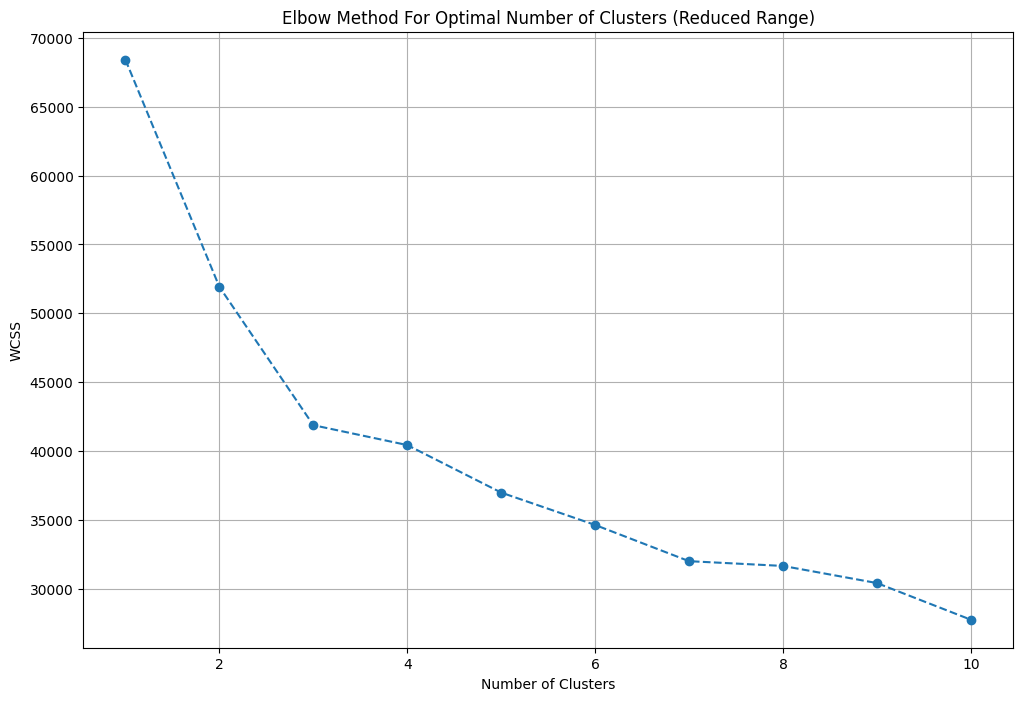

In [252]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [253]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

After Applying Elbow Method we can see for clusters = 3 we are finding the best results.

In [254]:
df = df.iloc[:,:-18]

In [255]:
df['furnishing_type'] = cluster_assignments

In [ ]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
2182,NaN,1
3597,NaN,1
3513,"['2 Wardrobe', '1 Exhaust Fan', '1 Geyser', '10 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1272,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '10 Light', '1 Modular Kitchen', '6 AC', '1 Curtains', '1 Chimney', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1508,"['4 Wardrobe', '8 Fan', '1 Fridge', '4 Geyser', '1 Washing Machine', '10 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']",0


# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

5. Handling Features Column

In [263]:
df[['society','features']].sample(5)

,society,features
3263,rof ananda,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Bank Attached Property', 'Visitor Parking', 'Natural Light', 'Airy Rooms', 'Shopping Centre']"
3366,alpha corp gurgaonone,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']"
1731,deepak minda,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1695,corona optus,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
6,experion the heartsong,"['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
